# Metodología de preprocesamiento

1. Visualizar al atributo a preprocesar 
2. Inferir la estrategia de preprocesamiento. 
3. Justificar la estrategia de preprocesamiento desde referentes teóricos. 

# Preprocesameinto de la variable objetivo 

Aplicar una transformación logarítmica a tu variable `casos_dengue` no solo es adecuado, sino que en este caso es **altamente recomendable**.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import PowerTransformer, StandardScaler

In [30]:
# Ubicación para guardar datos consolidados
ubicacion_datos_consolidados_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Datos consolidados"
ubicacion_datos_consolidados_marco = ""
# Ubicación para guardar las imágenes
ubicacion_imagenes_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Gráficos\05_ Preprocesamiento"
ubicacion_imagenes_marco = ""

In [28]:
path_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Datos consolidados\datos_semanal_meteo_epi.xlsx"
path_marco = r"C:\Users\marco\OneDrive - Universidad de Antioquia\Documentos\2_recursos_ensenanza\5_arima\6_datos_arima\4_base_datos_consolidada\datos_semanal_meteo_epi.xlsx"
datos_semanal_meteo_epi = pd.read_excel(path_janis)
# hacer que fecha sea el indice y sea de tipo datetime
datos_semanal_meteo_epi['fecha'] = pd.to_datetime(datos_semanal_meteo_epi['fecha']) # convertir en tipo datetime
datos_semanal_meteo_epi.set_index('fecha', inplace=True)  # hacer que fecha sea el indice 
datos_semanal_meteo_epi.head()

,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv,soi,sst,casos_dengue
fecha,,,,,,,,,,,,,,,,
2021-01-03,2021,1,28.254286,34.200000,23.832857,16.367143,70.774286,7.73,1,0.124286,0.268571,0.047143,2.222857,20.067143,-1.060214,0
2021-01-10,2021,2,28.638571,34.910000,24.195714,17.318571,73.095714,19.18,5,0.111429,0.204286,0.038571,2.254286,18.207143,-1.058352,0
2021-01-17,2021,3,29.552857,36.372857,24.090000,16.122857,65.328571,0.80,0,0.122857,0.227143,0.045714,2.420000,10.847143,-0.931407,1
2021-01-24,2021,4,29.208571,35.978571,24.200000,16.564286,68.205714,12.81,5,0.122857,0.220000,0.035714,2.477143,15.430000,-0.837360,0
2021-01-31,2021,5,29.421429,35.882857,24.684286,17.311429,69.797143,18.06,3,0.117143,0.225714,0.030000,2.290000,9.348571,-0.897892,0


In [11]:
datos_semanal_meteo_epi.columns 

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min',
       'uv', 'soi', 'sst', 'casos_dengue'],
      dtype='object')

In [12]:
datos_semanal_meteo_epi['casos_dengue'] 

fecha
2021-01-03    0
2021-01-10    0
2021-01-17    1
2021-01-24    0
2021-01-31    0
             ..
2025-11-30    8
2025-12-07    9
2025-12-14    7
2025-12-21    5
2025-12-28    9
Name: casos_dengue, Length: 261, dtype: int64

In [ ]:
# ====================== 1. COPIA DE SEGURIDAD ======================
datos_procesados = datos_semanal_meteo_epi.copy()

# ====================== 2. TRANSFORMACIONES DE NORMALIDAD ======================

# Logaritmo (para variables con muchos ceros)
datos_procesados['casos_ln']       = np.log(datos_procesados['casos_dengue'] + 1)
datos_procesados['prec_ln']        = np.log(datos_procesados['prec'] + 1)
datos_procesados['dias_lluvia_ln'] = np.log(datos_procesados['dias_lluvia'] + 1)

# Box-Cox para variables estrictamente positivas
vars_boxcox = ['temp', 'temp_max', 'temp_min', 'hum_esp', 'hum_rel',
               'vel_vi', 'vel_vi_max', 'vel_vi_min', 'uv']

for var in vars_boxcox:
    transformed, lam = boxcox(datos_procesados[var])
    datos_procesados[f'{var}_bc'] = transformed
    datos_procesados[f'{var}_bc_lambda'] = lam   # Guardamos lambda

# Yeo-Johnson
pt_soi = PowerTransformer(method='yeo-johnson')
pt_sst = PowerTransformer(method='yeo-johnson')

datos_procesados['soi_yj'] = pt_soi.fit_transform(datos_procesados[['soi']])
datos_procesados['sst_yj'] = pt_sst.fit_transform(datos_procesados[['sst']])

print("✅ Transformaciones de normalidad aplicadas")

# ====================== 3. ESTANDARIZACIÓN ======================

variables_a_estandarizar = [
    'casos_ln', 'prec_ln', 'dias_lluvia_ln',
    'temp_bc', 'temp_max_bc', 'temp_min_bc', 'hum_esp_bc', 'hum_rel_bc',
    'vel_vi_bc', 'vel_vi_max_bc', 'vel_vi_min_bc', 'uv_bc',
    'soi_yj', 'sst_yj'
]

scaler = StandardScaler()

datos_procesados[variables_a_estandarizar] = scaler.fit_transform(
    datos_procesados[variables_a_estandarizar]
)

print("Estandarización aplicada correctamente")

# ====================== 4. GUARDAR DOS VERSIONES DEL DATAFRAME ======================

# Asegurarnos que el índice sea de tipo datetime (por si acaso)
if not pd.api.types.is_datetime64_any_dtype(datos_procesados.index):
    datos_procesados.index = pd.to_datetime(datos_procesados.index)

# Crear versión SIN lambda (más limpia para modelado)
datos_sin_lambda = datos_procesados.drop(
    columns=[col for col in datos_procesados.columns if col.endswith('_lambda')]
).copy()

# Guardar versión SIN lambda
datos_sin_lambda.to_excel(
    f"{ubicacion_datos_consolidados_janis}/datos_procesados.xlsx", 
    index=True,                    # ← Importante: guardar el índice (fecha)
    sheet_name='datos_procesados'
)

# Guardar versión CON lambda (para invertir después)
datos_procesados.to_excel(
    f"{ubicacion_datos_consolidados_janis}/datos_procesados_con_lambda.xlsx", 
    index=True,                    # ← Guardar el índice (fecha)
    sheet_name='datos_procesados'
)

print("✅ Archivos guardados correctamente con fecha como índice:")
print(f"   → datos_procesados.xlsx   (sin columnas _lambda)")
print(f"   → datos_procesados_con_lambda.xlsx    (con lambdas guardados)")



✅ Transformaciones de normalidad aplicadas
✅ Estandarización aplicada correctamente
✅ Archivos guardados correctamente con fecha como índice:
   → datos_procesados.xlsx   (sin columnas _lambda)
   → datos_procesados_con_lambda.xlsx    (con lambdas guardados)


In [23]:
datos_procesados_sin_rezagos = pd.read_excel(
    f"{ubicacion_datos_consolidados_janis}/datos_procesados.xlsx")

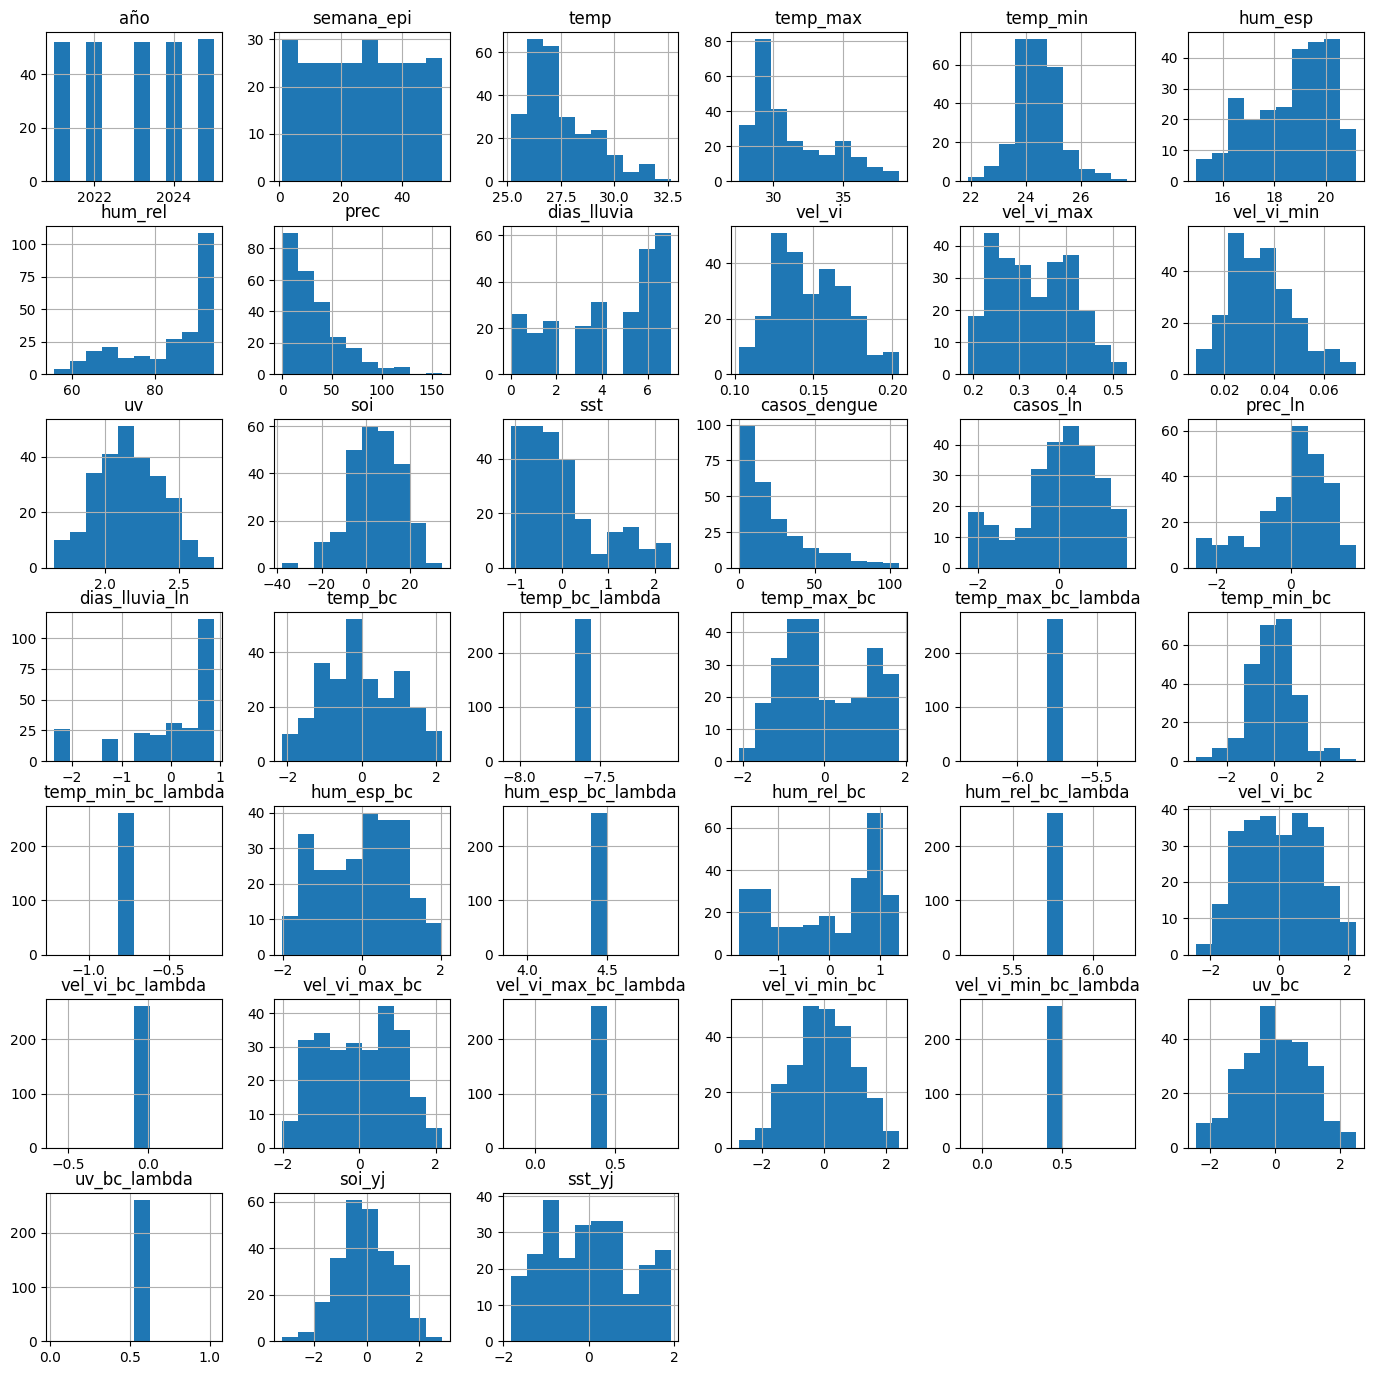

In [31]:
# Histogramas de todas las variables transformadas y estandarizadas sin las columnas de lambda
datos_procesados.hist(figsize=(17,17))
plt.savefig(f"{ubicacion_imagenes_janis}/1.histogramas_datos_procesados.png")
plt.show()

In [47]:
datos_procesados.columns

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min',
       'uv', 'soi', 'sst', 'casos_dengue', 'casos_ln', 'prec_ln',
       'dias_lluvia_ln', 'temp_bc', 'temp_bc_lambda', 'temp_max_bc',
       'temp_max_bc_lambda', 'temp_min_bc', 'temp_min_bc_lambda', 'hum_esp_bc',
       'hum_esp_bc_lambda', 'hum_rel_bc', 'hum_rel_bc_lambda', 'vel_vi_bc',
       'vel_vi_bc_lambda', 'vel_vi_max_bc', 'vel_vi_max_bc_lambda',
       'vel_vi_min_bc', 'vel_vi_min_bc_lambda', 'uv_bc', 'uv_bc_lambda',
       'soi_yj', 'sst_yj'],
      dtype='object')

In [32]:
datos_procesados.head()

,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,...,vel_vi_bc,vel_vi_bc_lambda,vel_vi_max_bc,vel_vi_max_bc_lambda,vel_vi_min_bc,vel_vi_min_bc_lambda,uv_bc,uv_bc_lambda,soi_yj,sst_yj
fecha,,,,,,,,,,,,,,,,,,,,,
2021-01-03,2021,1,28.254286,34.200000,23.832857,16.367143,70.774286,7.73,1,0.124286,...,-1.110633,-0.087219,-0.752514,0.347244,0.970687,0.410272,0.284735,0.525184,1.432593,-1.726035
2021-01-10,2021,2,28.638571,34.910000,24.195714,17.318571,73.095714,19.18,5,0.111429,...,-1.864950,-0.087219,-1.741631,0.347244,0.390308,0.410272,0.424653,0.525184,1.251647,-1.721237
2021-01-17,2021,3,29.552857,36.372857,24.090000,16.122857,65.328571,0.80,0,0.122857,...,-1.190152,-0.087219,-1.369313,0.347244,0.878558,0.410272,1.147566,0.525184,0.545162,-1.403882
2021-01-24,2021,4,29.208571,35.978571,24.200000,16.564286,68.205714,12.81,5,0.122857,...,-1.190152,-0.087219,-1.482924,0.347244,0.180094,0.410272,1.391362,0.525184,0.983127,-1.181283
2021-01-31,2021,5,29.421429,35.882857,24.684286,17.311429,69.797143,18.06,3,0.117143,...,-1.518601,-0.087219,-1.391847,0.347244,-0.272288,0.410272,0.582532,0.525184,0.403642,-1.323334



Calculando correlaciones cruzadas y guardando gráficos...



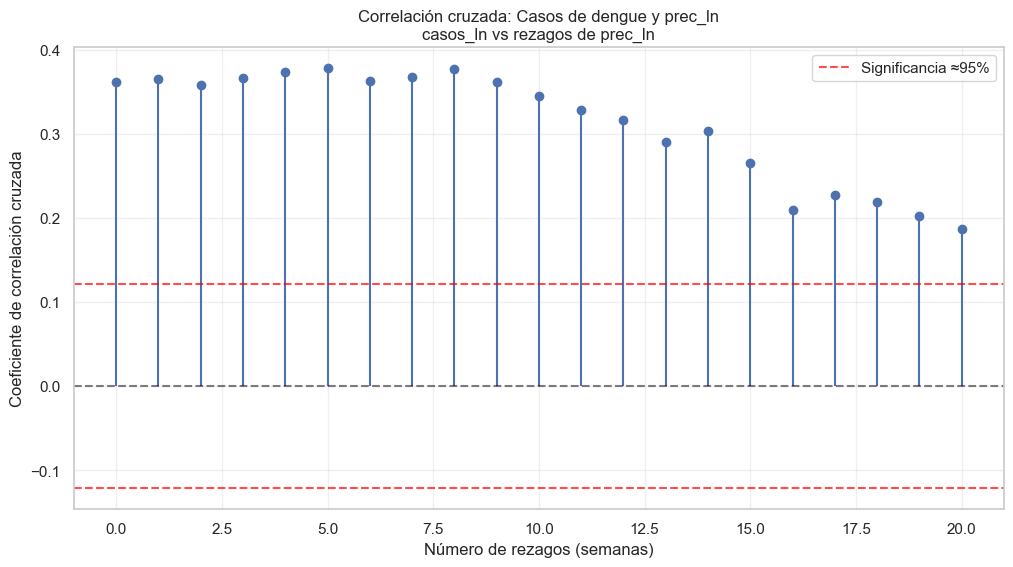


=== Rezagos más relevantes para casos_ln vs prec_ln ===
Lag  1: +0.3657
Lag  2: +0.3587
Lag  3: +0.3667
Lag  4: +0.3744
Lag  5: +0.3784
Lag  6: +0.3633
Lag  7: +0.3681
Lag  8: +0.3778
Lag  9: +0.3626
Lag 10: +0.3448
Lag 11: +0.3293
Lag 12: +0.3168
Lag 13: +0.2905
Lag 14: +0.3041
Lag 15: +0.2651
Lag 16: +0.2102
Lag 17: +0.2281
Lag 18: +0.2192
Lag 19: +0.2023
Lag 20: +0.1872
------------------------------------------------------------


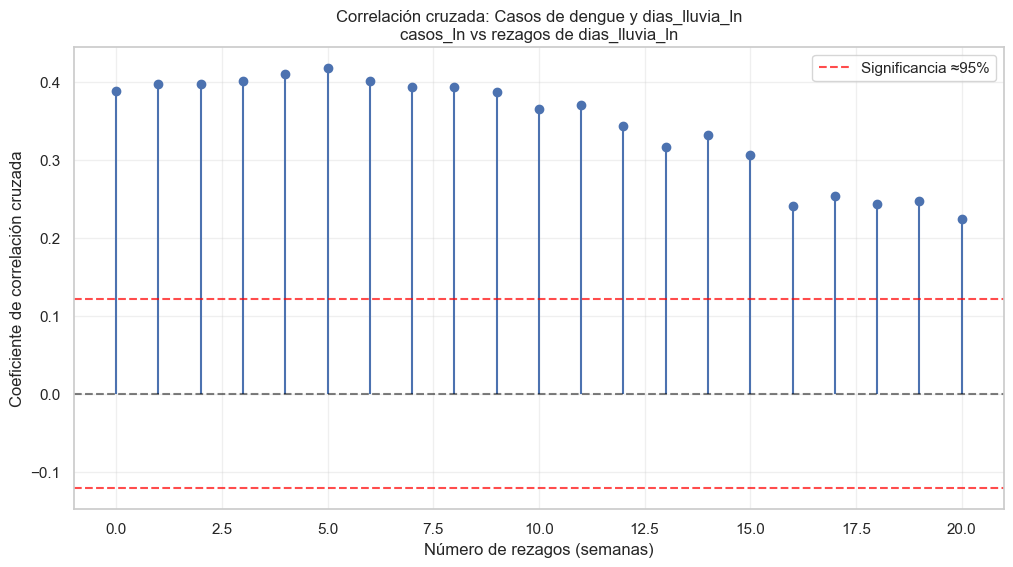


=== Rezagos más relevantes para casos_ln vs dias_lluvia_ln ===
Lag  1: +0.3976
Lag  2: +0.3974
Lag  3: +0.4008
Lag  4: +0.4096
Lag  5: +0.4175
Lag  6: +0.4010
Lag  7: +0.3931
Lag  8: +0.3935
Lag  9: +0.3872
Lag 10: +0.3655
Lag 11: +0.3706
Lag 12: +0.3434
Lag 13: +0.3164
Lag 14: +0.3320
Lag 15: +0.3057
Lag 16: +0.2403
Lag 17: +0.2536
Lag 18: +0.2430
Lag 19: +0.2476
Lag 20: +0.2245
------------------------------------------------------------


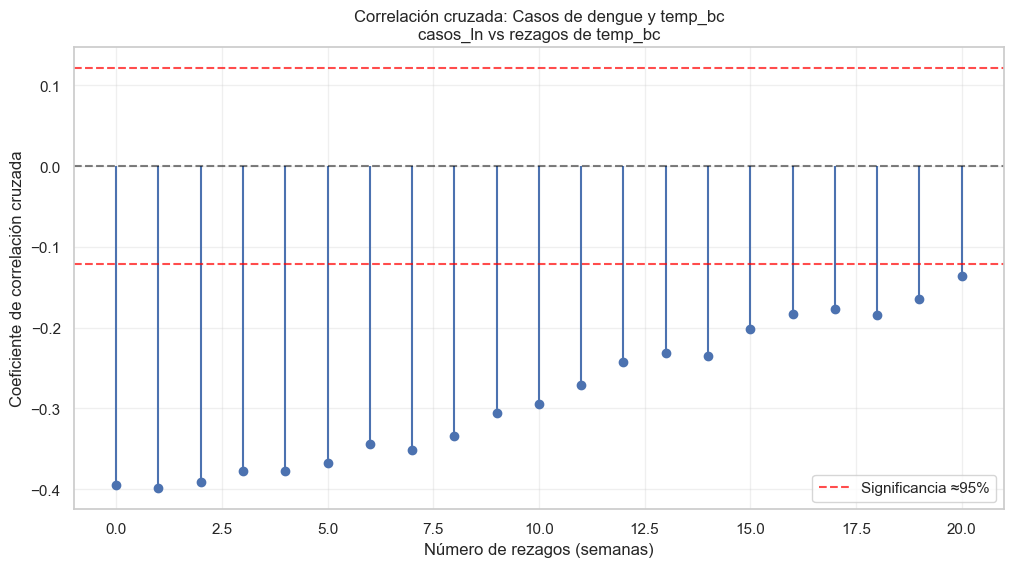


=== Rezagos más relevantes para casos_ln vs temp_bc ===
Lag  1: -0.3988
Lag  2: -0.3912
Lag  3: -0.3773
Lag  4: -0.3773
Lag  5: -0.3680
Lag  6: -0.3437
Lag  7: -0.3512
Lag  8: -0.3339
Lag  9: -0.3055
Lag 10: -0.2940
Lag 11: -0.2706
Lag 12: -0.2430
Lag 13: -0.2309
Lag 14: -0.2349
Lag 15: -0.2022
Lag 16: -0.1832
Lag 17: -0.1771
Lag 18: -0.1845
Lag 19: -0.1642
------------------------------------------------------------


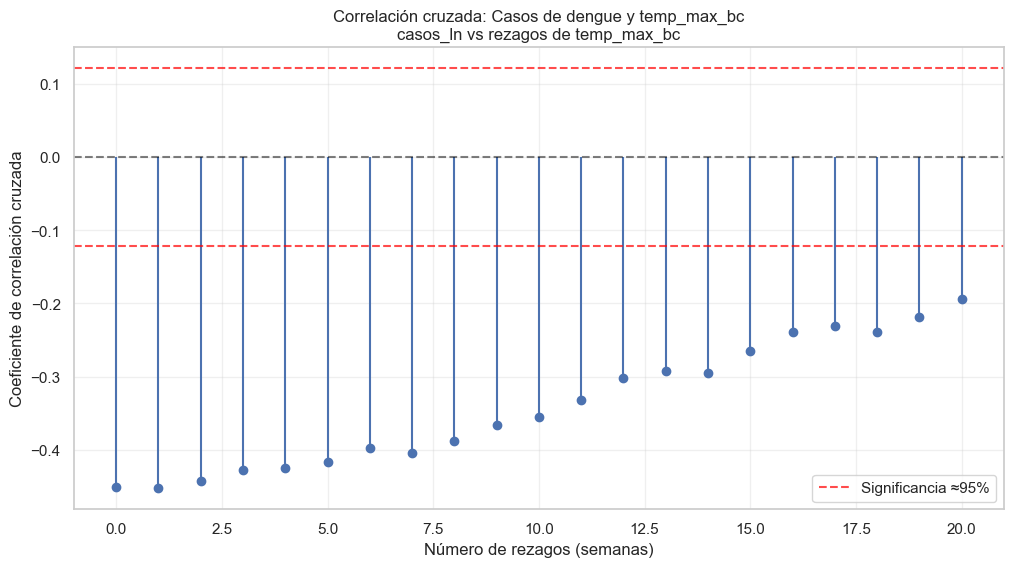


=== Rezagos más relevantes para casos_ln vs temp_max_bc ===
Lag  1: -0.4525
Lag  2: -0.4425
Lag  3: -0.4277
Lag  4: -0.4247
Lag  5: -0.4161
Lag  6: -0.3981
Lag  7: -0.4044
Lag  8: -0.3880
Lag  9: -0.3666
Lag 10: -0.3554
Lag 11: -0.3321
Lag 12: -0.3018
Lag 13: -0.2919
Lag 14: -0.2944
Lag 15: -0.2655
Lag 16: -0.2397
Lag 17: -0.2307
Lag 18: -0.2384
Lag 19: -0.2179
Lag 20: -0.1945
------------------------------------------------------------


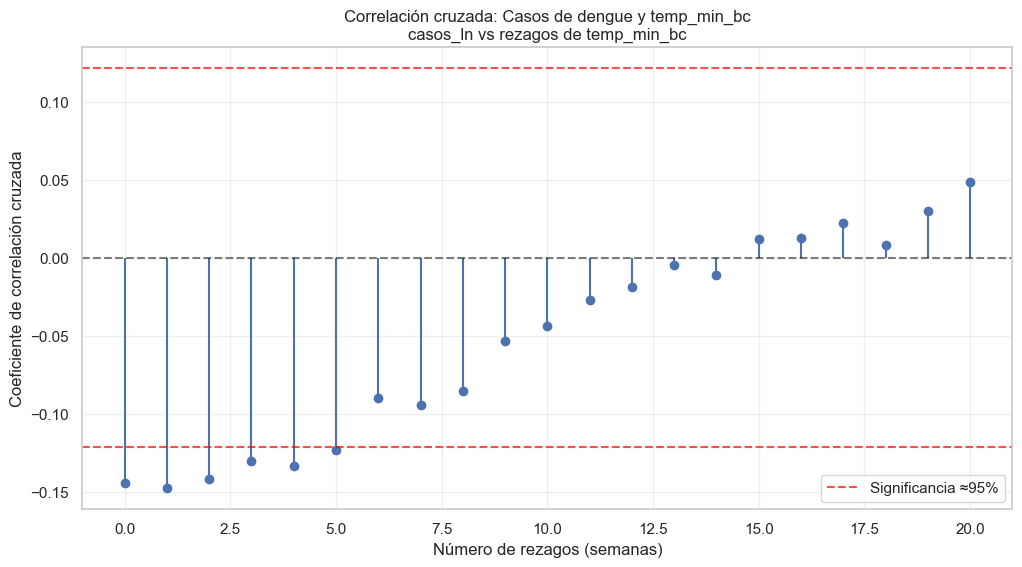


=== Rezagos más relevantes para casos_ln vs temp_min_bc ===
------------------------------------------------------------


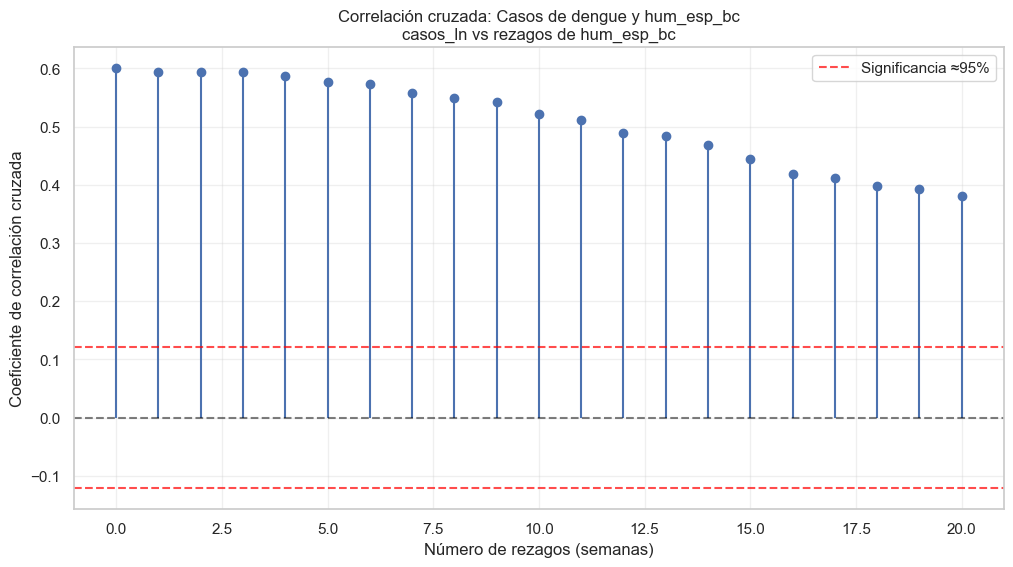


=== Rezagos más relevantes para casos_ln vs hum_esp_bc ===
Lag  1: +0.5946
Lag  2: +0.5932
Lag  3: +0.5943
Lag  4: +0.5867
Lag  5: +0.5762
Lag  6: +0.5739
Lag  7: +0.5573
Lag  8: +0.5486
Lag  9: +0.5421
Lag 10: +0.5223
Lag 11: +0.5110
Lag 12: +0.4884
Lag 13: +0.4843
Lag 14: +0.4683
Lag 15: +0.4447
Lag 16: +0.4182
Lag 17: +0.4116
Lag 18: +0.3976
Lag 19: +0.3923
Lag 20: +0.3812
------------------------------------------------------------


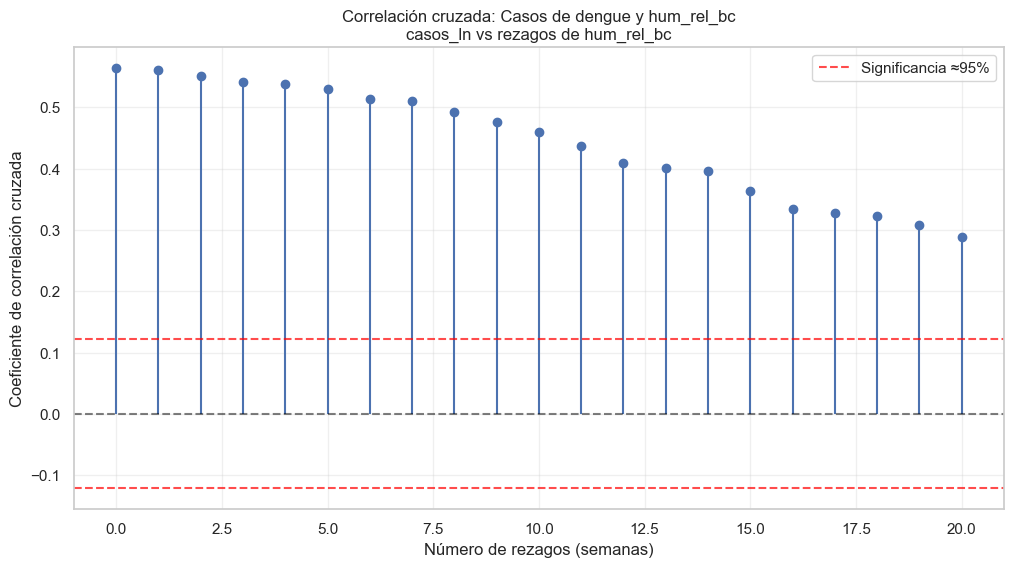


=== Rezagos más relevantes para casos_ln vs hum_rel_bc ===
Lag  1: +0.5603
Lag  2: +0.5509
Lag  3: +0.5414
Lag  4: +0.5374
Lag  5: +0.5291
Lag  6: +0.5132
Lag  7: +0.5097
Lag  8: +0.4928
Lag  9: +0.4754
Lag 10: +0.4590
Lag 11: +0.4375
Lag 12: +0.4089
Lag 13: +0.4009
Lag 14: +0.3953
Lag 15: +0.3633
Lag 16: +0.3345
Lag 17: +0.3275
Lag 18: +0.3224
Lag 19: +0.3076
Lag 20: +0.2880
------------------------------------------------------------


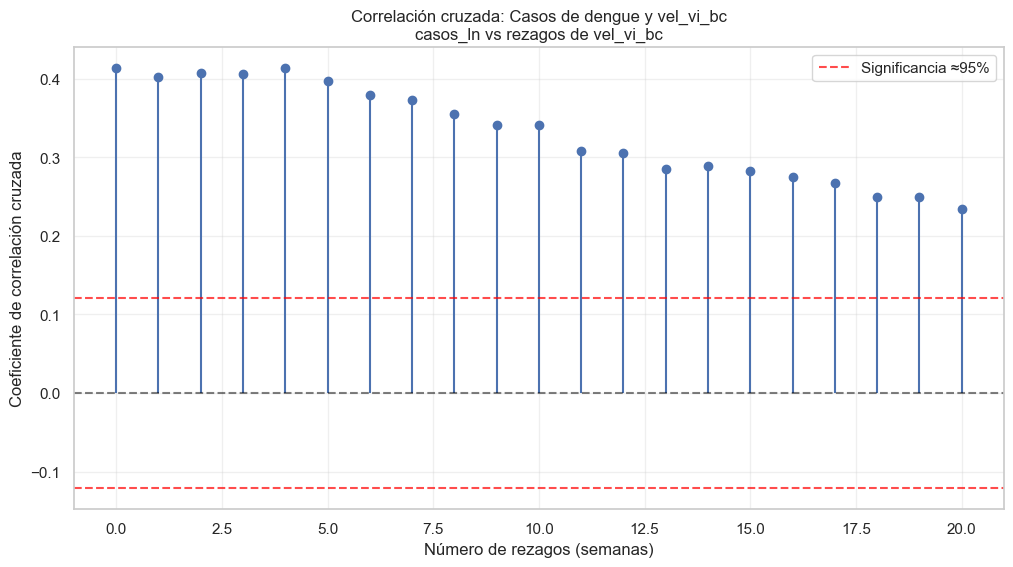


=== Rezagos más relevantes para casos_ln vs vel_vi_bc ===
Lag  1: +0.4024
Lag  2: +0.4070
Lag  3: +0.4065
Lag  4: +0.4136
Lag  5: +0.3971
Lag  6: +0.3796
Lag  7: +0.3732
Lag  8: +0.3557
Lag  9: +0.3407
Lag 10: +0.3416
Lag 11: +0.3079
Lag 12: +0.3058
Lag 13: +0.2852
Lag 14: +0.2889
Lag 15: +0.2825
Lag 16: +0.2750
Lag 17: +0.2670
Lag 18: +0.2491
Lag 19: +0.2492
Lag 20: +0.2341
------------------------------------------------------------


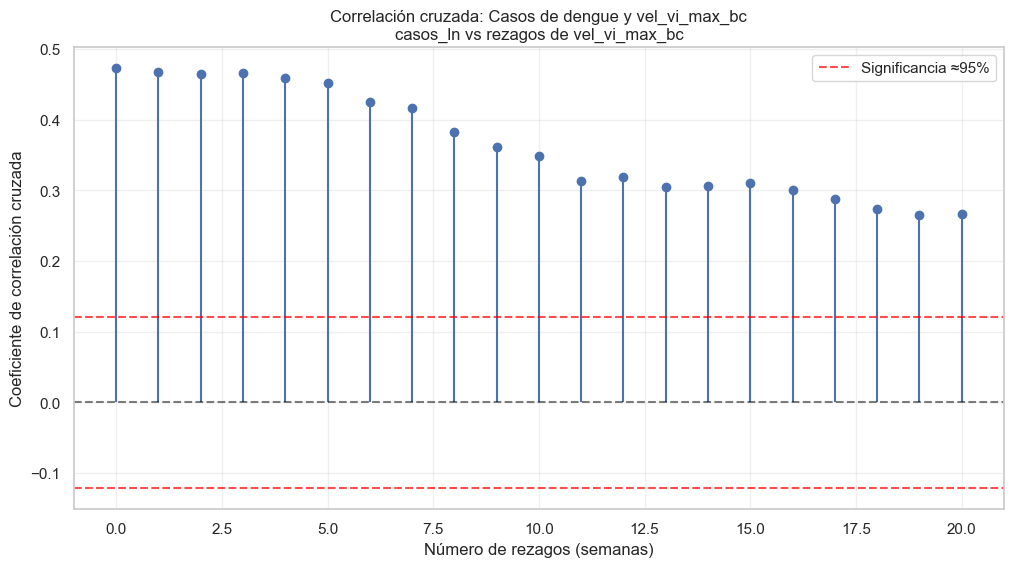


=== Rezagos más relevantes para casos_ln vs vel_vi_max_bc ===
Lag  1: +0.4669
Lag  2: +0.4651
Lag  3: +0.4662
Lag  4: +0.4582
Lag  5: +0.4521
Lag  6: +0.4251
Lag  7: +0.4162
Lag  8: +0.3832
Lag  9: +0.3610
Lag 10: +0.3485
Lag 11: +0.3137
Lag 12: +0.3182
Lag 13: +0.3053
Lag 14: +0.3062
Lag 15: +0.3103
Lag 16: +0.2998
Lag 17: +0.2878
Lag 18: +0.2743
Lag 19: +0.2650
Lag 20: +0.2661
------------------------------------------------------------


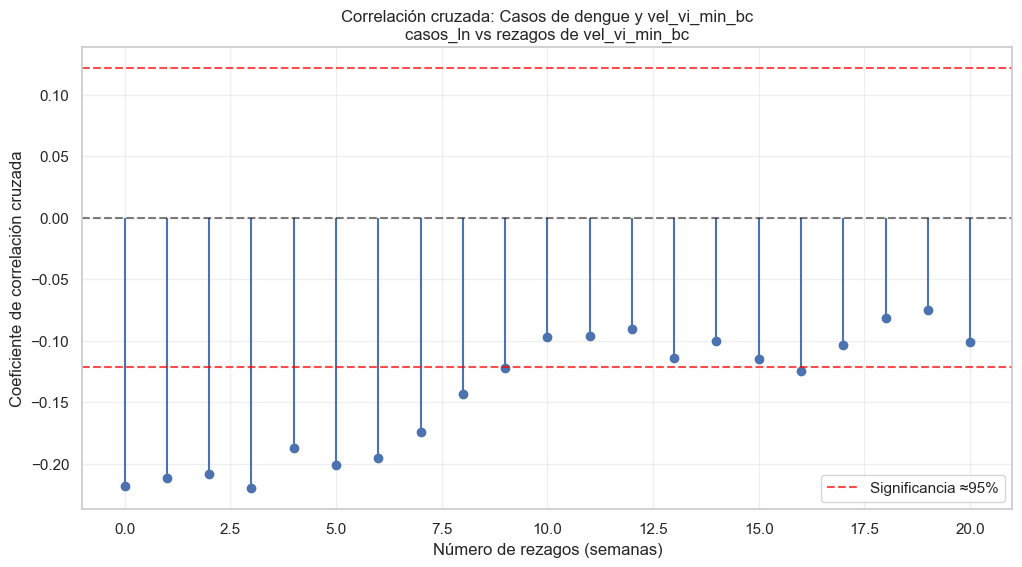


=== Rezagos más relevantes para casos_ln vs vel_vi_min_bc ===
Lag  1: -0.2113
Lag  2: -0.2084
Lag  3: -0.2198
Lag  4: -0.1874
Lag  5: -0.2006
Lag  6: -0.1951
Lag  7: -0.1744
------------------------------------------------------------


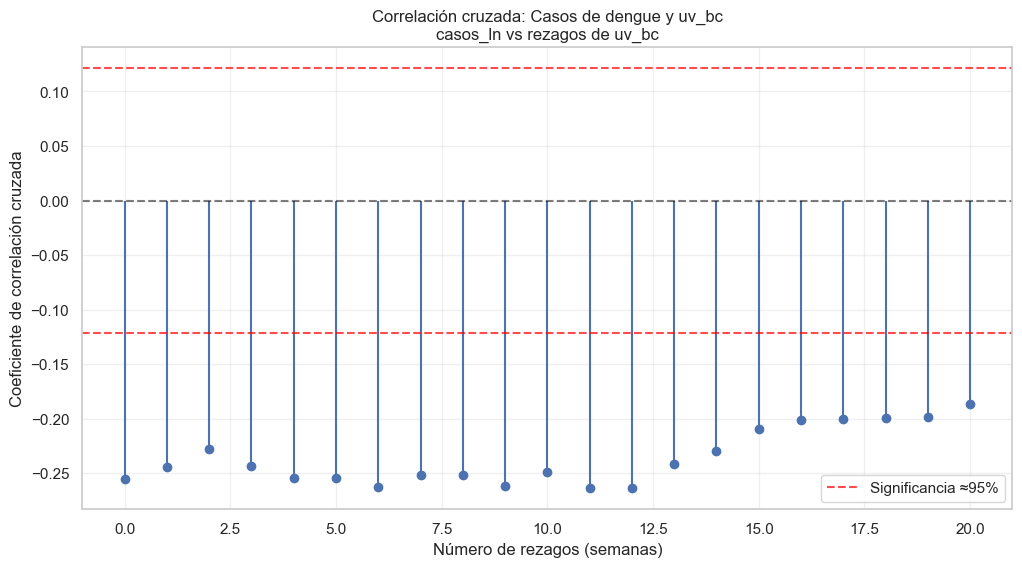


=== Rezagos más relevantes para casos_ln vs uv_bc ===
Lag  1: -0.2448
Lag  2: -0.2282
Lag  3: -0.2435
Lag  4: -0.2549
Lag  5: -0.2547
Lag  6: -0.2632
Lag  7: -0.2522
Lag  8: -0.2515
Lag  9: -0.2616
Lag 10: -0.2493
Lag 11: -0.2639
Lag 12: -0.2635
Lag 13: -0.2414
Lag 14: -0.2300
Lag 15: -0.2093
Lag 16: -0.2013
Lag 17: -0.2003
Lag 18: -0.1995
Lag 19: -0.1981
Lag 20: -0.1864
------------------------------------------------------------


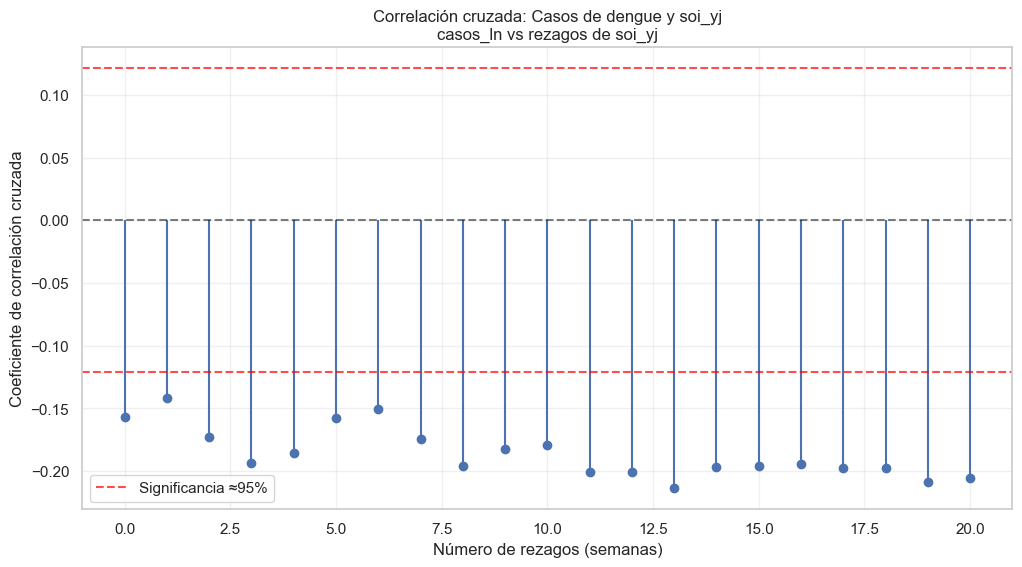


=== Rezagos más relevantes para casos_ln vs soi_yj ===
Lag  2: -0.1732
Lag  3: -0.1936
Lag  4: -0.1860
Lag  5: -0.1574
Lag  6: -0.1501
Lag  7: -0.1748
Lag  8: -0.1962
Lag  9: -0.1828
Lag 10: -0.1797
Lag 11: -0.2012
Lag 12: -0.2005
Lag 13: -0.2138
Lag 14: -0.1968
Lag 15: -0.1960
Lag 16: -0.1946
Lag 17: -0.1976
Lag 18: -0.1977
Lag 19: -0.2089
Lag 20: -0.2060
------------------------------------------------------------


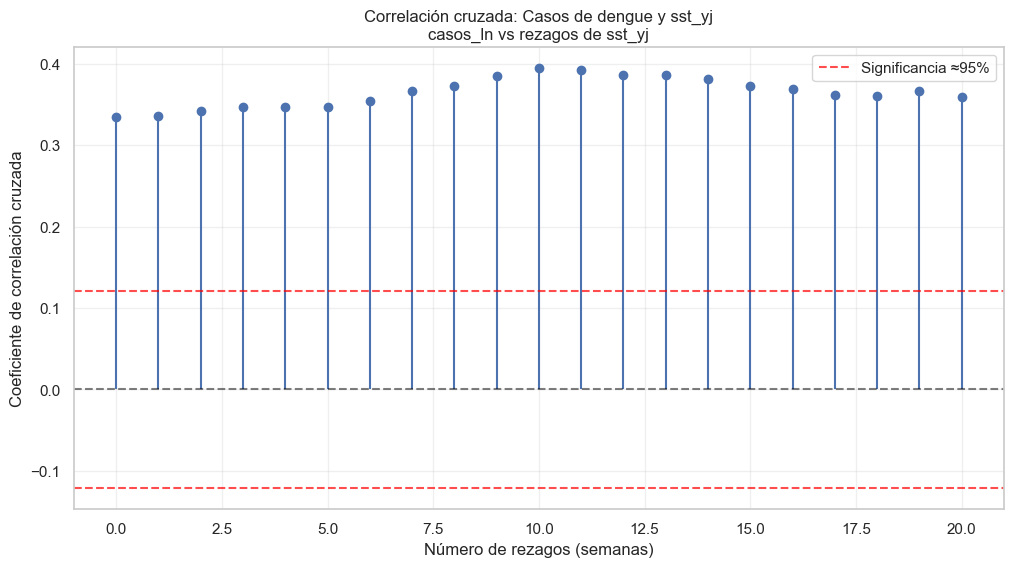


=== Rezagos más relevantes para casos_ln vs sst_yj ===
Lag  1: +0.3360
Lag  2: +0.3416
Lag  3: +0.3462
Lag  4: +0.3463
Lag  5: +0.3465
Lag  6: +0.3535
Lag  7: +0.3663
Lag  8: +0.3731
Lag  9: +0.3843
Lag 10: +0.3944
Lag 11: +0.3918
Lag 12: +0.3861
Lag 13: +0.3857
Lag 14: +0.3806
Lag 15: +0.3722
Lag 16: +0.3683
Lag 17: +0.3610
Lag 18: +0.3597
Lag 19: +0.3660
Lag 20: +0.3585
------------------------------------------------------------


In [49]:
# ====================== Función para calcular y graficar CCF ====================== 
def plot_cross_correlation(df, var_x, var_y, max_lags=20, title="", save_path=None):
    """
    Calcula y grafica la correlación cruzada entre dos series
    """
    x = df[var_x].values
    y = df[var_y].values
    
    # Calcular correlación cruzada
    correlation = signal.correlate(y - np.mean(y), x - np.mean(x), mode='full')
    lags = signal.correlation_lags(len(y), len(x), mode='full')
    
    # Normalizar
    correlation = correlation / (np.std(y) * np.std(x) * len(y))
    
    # Solo lags positivos (0 en adelante)
    pos_mask = lags >= 0
    lags_pos = lags[pos_mask][:max_lags+1]
    corr_pos = correlation[pos_mask][:max_lags+1]
    
    # Graficar
    plt.figure(figsize=(12, 6))
    plt.stem(lags_pos, corr_pos, basefmt=" ")
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.axhline(y=1.96/np.sqrt(len(y)), color='red', linestyle='--', alpha=0.7, label='Significancia ≈95%')
    plt.axhline(y=-1.96/np.sqrt(len(y)), color='red', linestyle='--', alpha=0.7)
    
    plt.title(f'Correlación cruzada: {title}\n{var_y} vs rezagos de {var_x}')
    plt.xlabel('Número de rezagos (semanas)')
    plt.ylabel('Coeficiente de correlación cruzada')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Guardar la imagen ANTES de show()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Mostrar rezagos relevantes
    print(f"\n=== Rezagos más relevantes para {var_y} vs {var_x} ===")
    for i in range(1, max_lags+1):
        if abs(corr_pos[i]) > 0.15:
            sign = "+" if corr_pos[i] > 0 else ""
            print(f"Lag {i:2d}: {sign}{corr_pos[i]:.4f}")
    print("-" * 60)


# ====================== 5. Calcular CCF y guardar gráficos ======================

variables_a_analizar = [
    'prec_ln', 'dias_lluvia_ln', 'temp_bc', 'temp_max_bc', 'temp_min_bc',
    'hum_esp_bc', 'hum_rel_bc', 'vel_vi_bc', 'vel_vi_max_bc',
    'vel_vi_min_bc', 'uv_bc', 'soi_yj', 'sst_yj'
]

print("\nCalculando correlaciones cruzadas y guardando gráficos...\n")

for var in variables_a_analizar:
    filename = f"ccf_casos_dengue_{var}.png"
    save_path = f"{ubicacion_imagenes_janis}/2.{filename}"
    
    plot_cross_correlation(
        df=datos_procesados_sin_rezagos,  
        var_x=var,
        var_y='casos_ln',
        max_lags=20,
        title=f"Casos de dengue y {var}",
        save_path=save_path          # ← Ahora pasamos la ruta
    )

In [57]:
datos_semanal_meteo_epi.columns

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min',
       'uv', 'soi', 'sst', 'casos_dengue'],
      dtype='object')

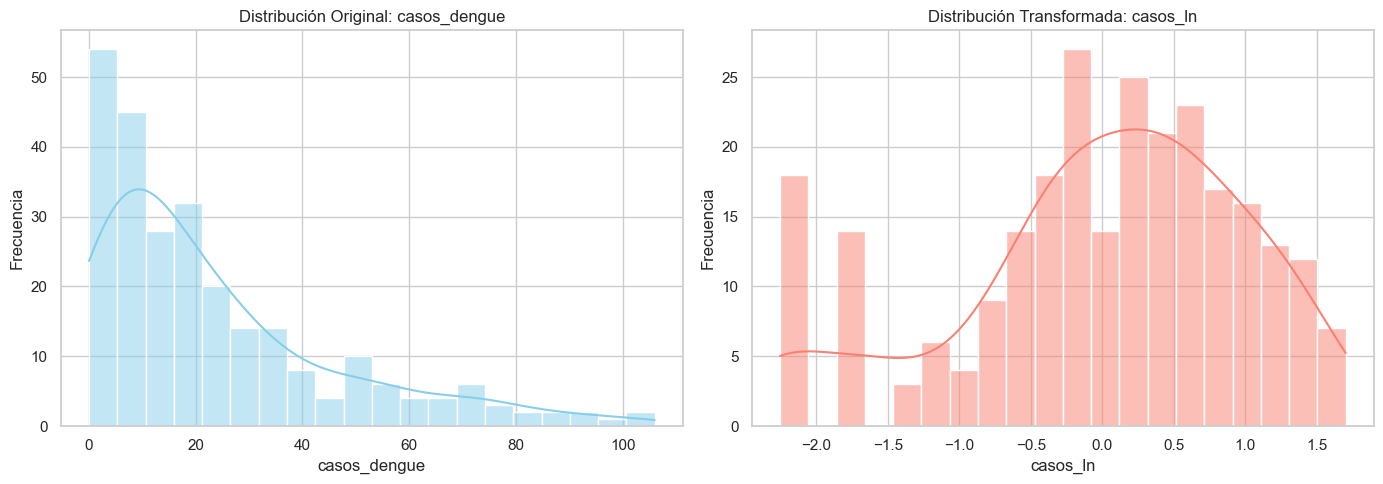

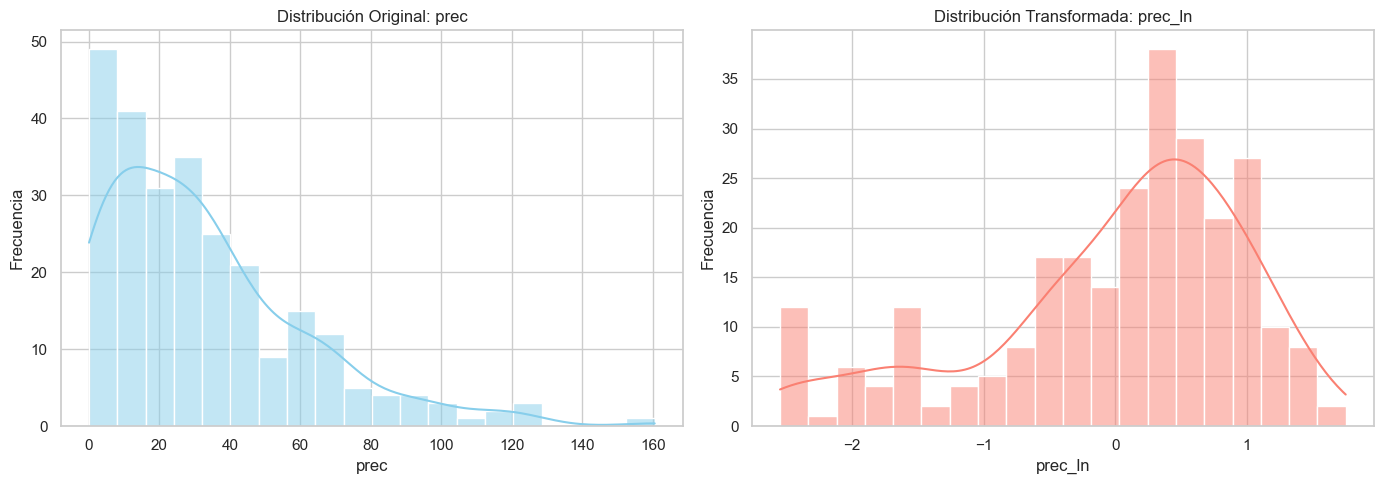

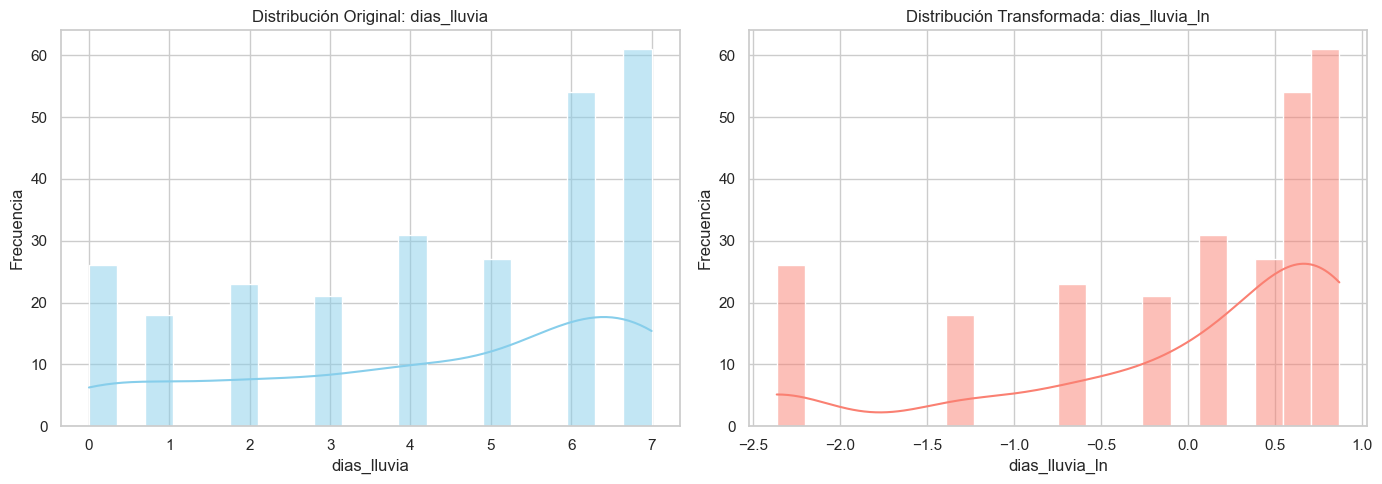

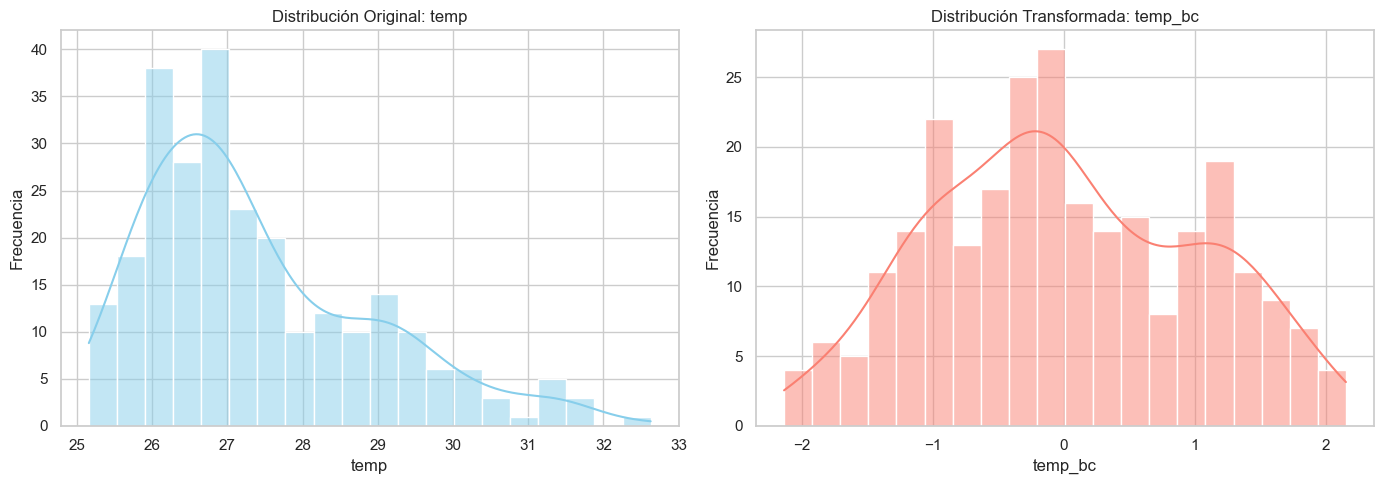

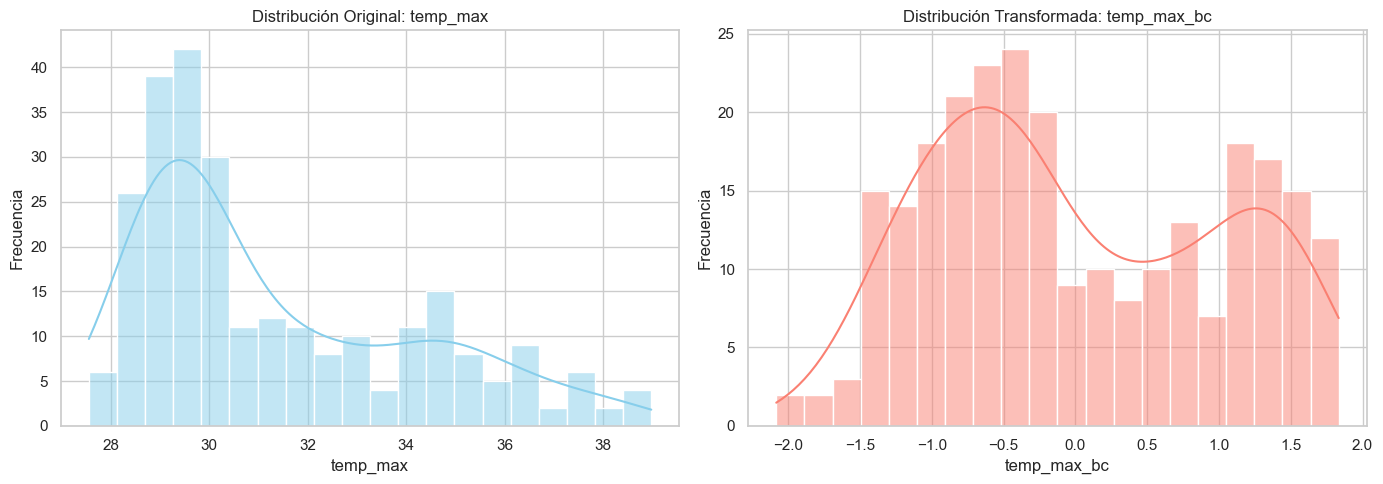

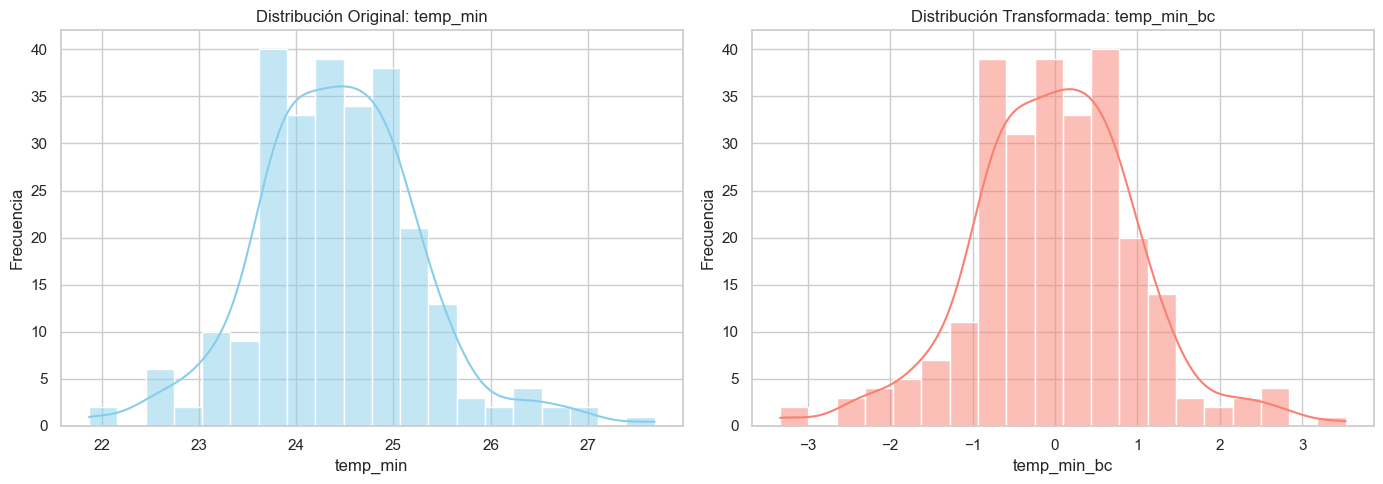

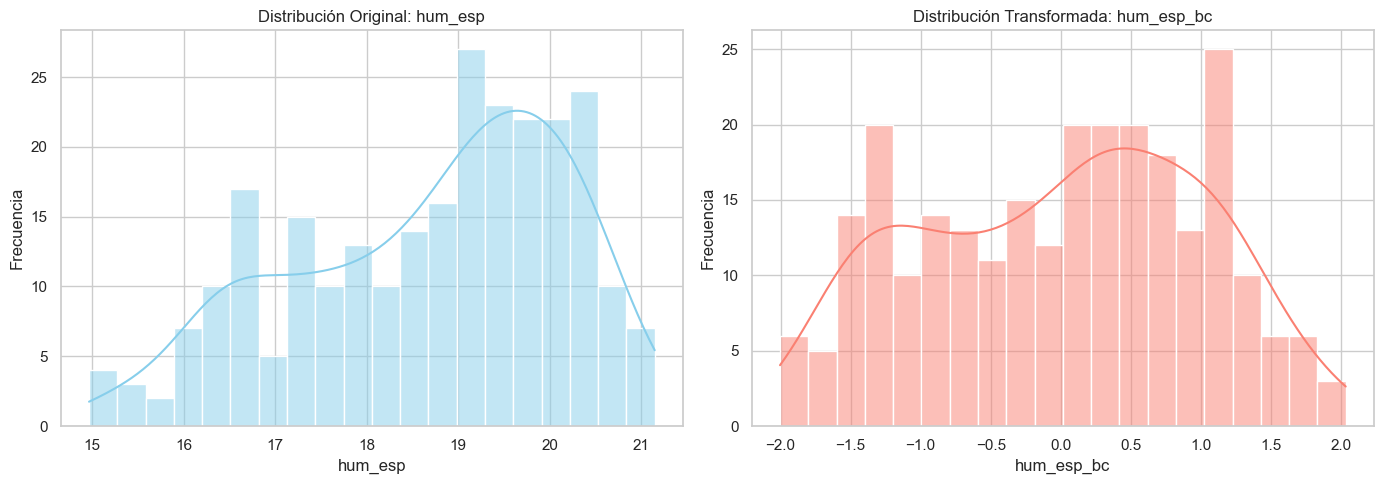

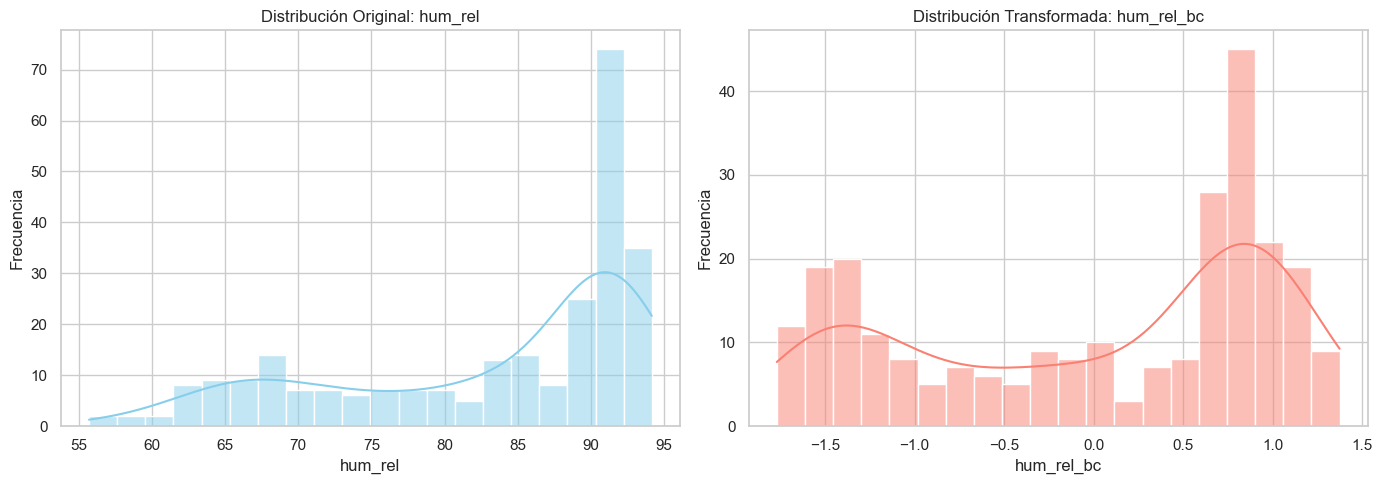

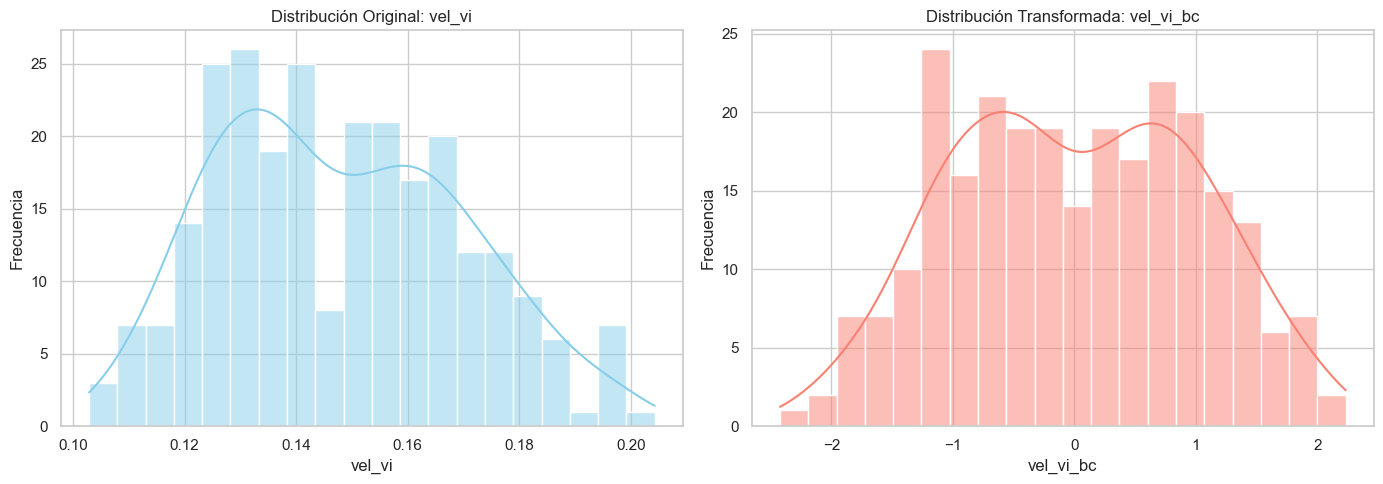

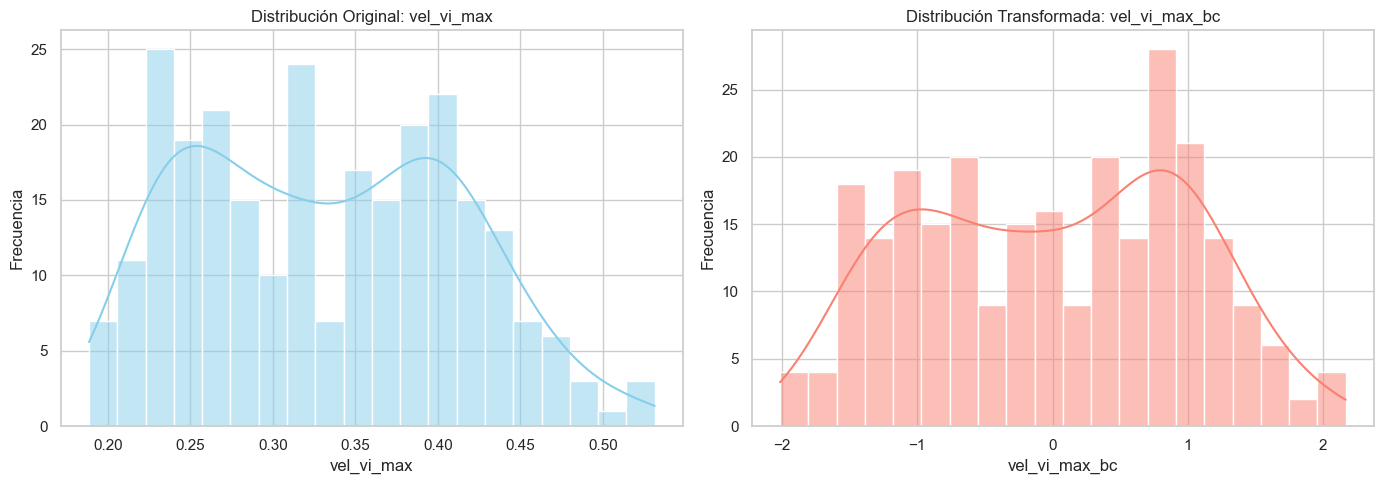

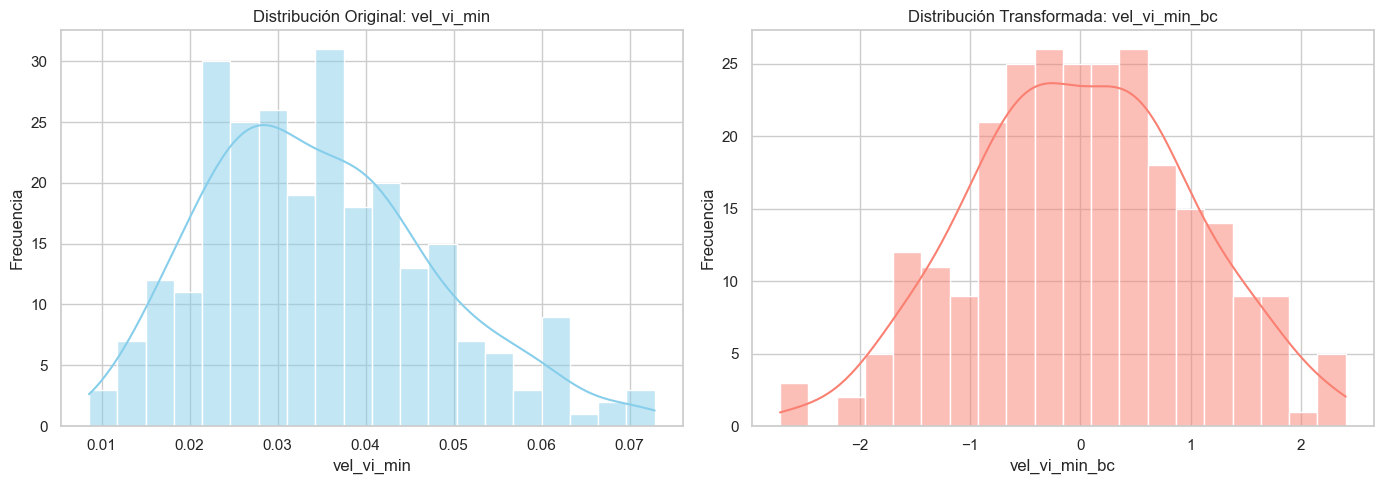

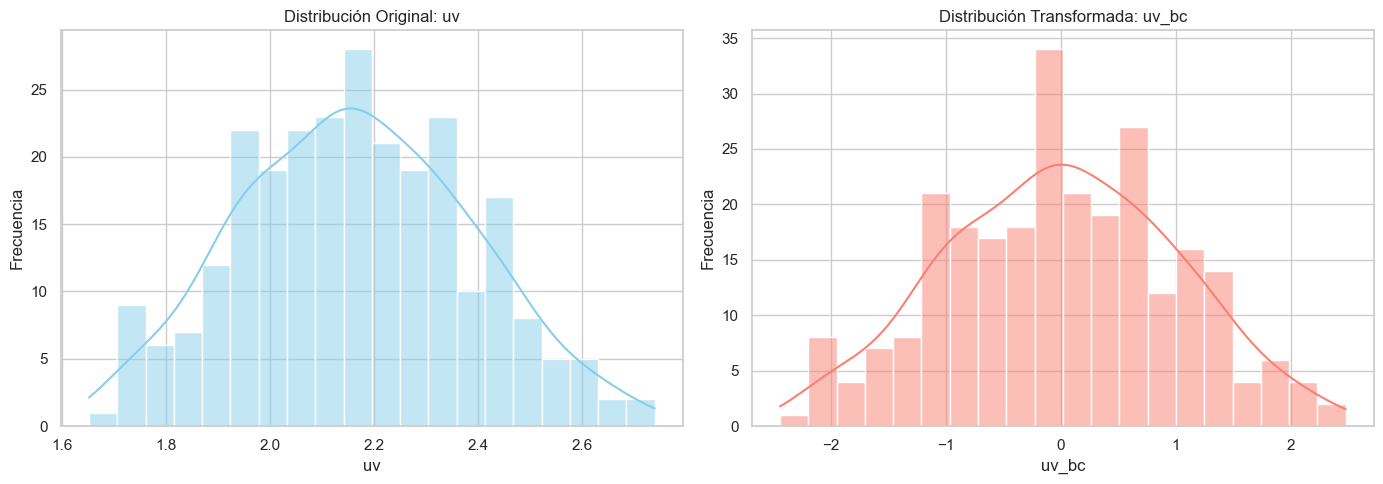

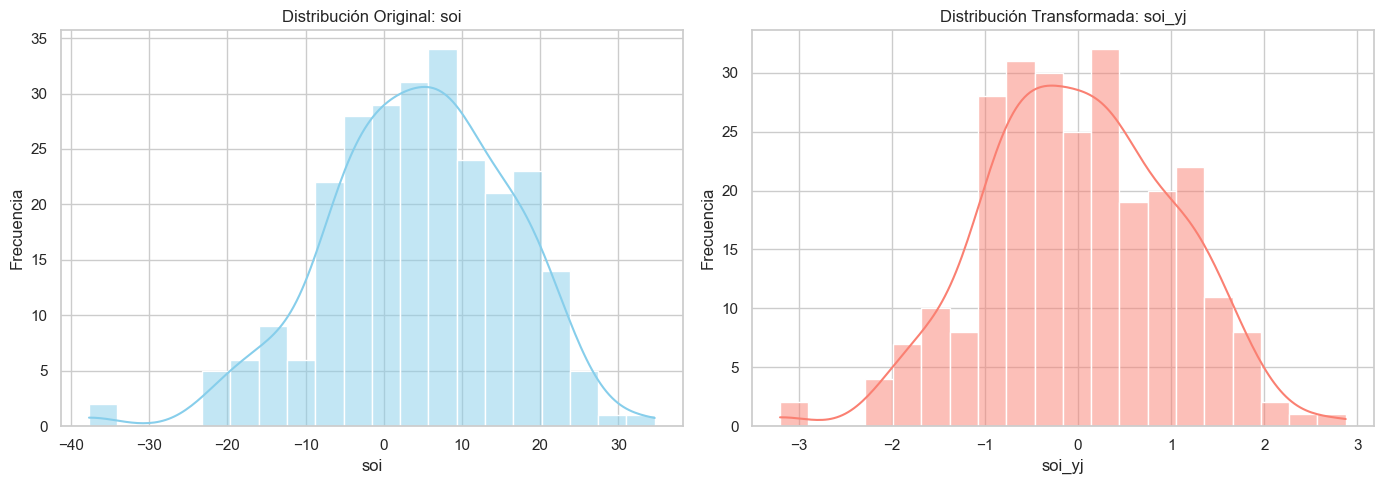

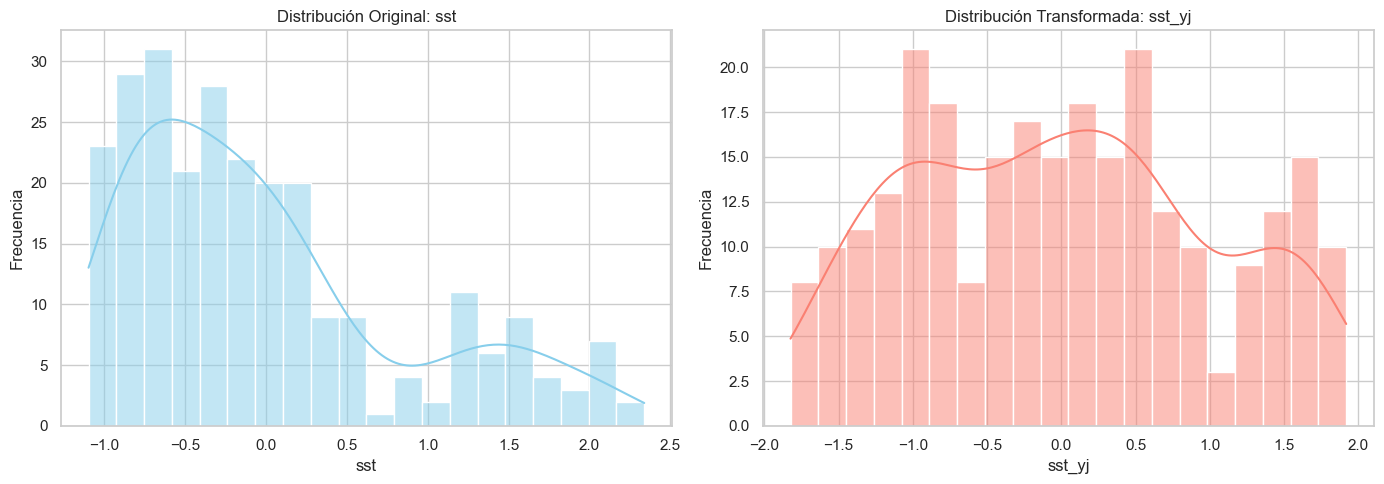

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo (igual al de tu imagen)
sns.set(style="whitegrid")

# Diccionario de variables
variables_hist = {
    'casos_dengue': 'casos_ln',
    'prec': 'prec_ln',
    'dias_lluvia': 'dias_lluvia_ln',
    'temp': 'temp_bc',
    'temp_max': 'temp_max_bc',
    'temp_min': 'temp_min_bc',
    'hum_esp': 'hum_esp_bc',
    'hum_rel': 'hum_rel_bc',
    'vel_vi': 'vel_vi_bc',
    'vel_vi_max': 'vel_vi_max_bc',
    'vel_vi_min': 'vel_vi_min_bc',
    'uv': 'uv_bc',
    'soi': 'soi_yj',
    'sst': 'sst_yj',
}

# ====================== Histogramas tipo publicación ======================
for var_original, var_transformada in variables_hist.items():
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 🔵 ORIGINAL
    sns.histplot(
        datos_semanal_meteo_epi[var_original].dropna(),
        bins=20,
        kde=True,
        ax=axes[0],
        color="skyblue"
    )
    axes[0].set_title(f'Distribución Original: {var_original}')
    axes[0].set_xlabel(var_original)
    axes[0].set_ylabel('Frecuencia')
    
    # 🔴 TRANSFORMADA
    sns.histplot(
        datos_procesados[var_transformada].dropna(),
        bins=20,
        kde=True,
        ax=axes[1],
        color="salmon"
    )
    axes[1].set_title(f'Distribución Transformada: {var_transformada}')
    axes[1].set_xlabel(var_transformada)
    axes[1].set_ylabel('Frecuencia')
    
    plt.tight_layout()
    
    # Guardar imagen
    save_path = f"{ubicacion_imagenes_janis}/3.histograma_{var_original}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close()


In [50]:
import pandas as pd

# Datos de la tabla de rezagos relevantes
data = {
    'Variable': [
        'hum_esp_bc', 'hum_rel_bc', 'vel_vi_max_bc', 'temp_max_bc', 
        'vel_vi_bc', 'dias_lluvia_ln', 'prec_ln', 'temp_bc', 
        'sst_yj', 'uv_bc', 'soi_yj', 'vel_vi_min_bc'
    ],
    'Rezagos más fuertes': [
        'Lag 1: +0.5946, Lag 2: +0.5932, Lag 3: +0.5943',
        'Lag 1: +0.5603, Lag 2: +0.5509, Lag 3: +0.5414',
        'Lag 1: +0.4669, Lag 2: +0.4651, Lag 3: +0.4662',
        'Lag 1: -0.4525, Lag 2: -0.4425',
        'Lag 4: +0.4136, Lag 2: +0.4070',
        'Lag 5: +0.4175, Lag 4: +0.4096',
        'Lag 5: +0.3784, Lag 8: +0.3778',
        'Lag 1: -0.3988, Lag 2: -0.3912',
        'Lag 10: +0.3944, Lag 9: +0.3843',
        'Lag 11: -0.2639, Lag 6: -0.2632',
        'Lag 13: -0.2138',
        'Lag 3: -0.2198'
    ],
    'Correlación más alta': [
        '+0.5946', '+0.5603', '+0.4669', '-0.4525',
        '+0.4136', '+0.4175', '+0.3784', '-0.3988',
        '+0.3944', '-0.2639', '-0.2138', '-0.2198'
    ],
    'Tipo de correlación': [
        'Muy fuerte positiva', 'Muy fuerte positiva', 'Fuerte positiva',
        'Fuerte negativa', 'Moderada positiva', 'Moderada positiva',
        'Moderada positiva', 'Moderada negativa', 'Moderada positiva (retrasada)',
        'Débil negativa', 'Débil negativa', 'Débil negativa'
    ]
}

# Crear el DataFrame
tabla_rezagos = pd.DataFrame(data)

# Mostrar la tabla de forma bonita en Jupyter / VS Code
display(tabla_rezagos)

# Opcional: Guardar como Excel o CSV para tenerla siempre
tabla_rezagos.to_excel(ubicacion_datos_consolidados_janis + '/rezagos_relevantes_dengue.xlsx', index=False)

print("✅ Tabla creada y guardada como 'rezagos_relevantes_dengue.xlsx'")

,Variable,Rezagos más fuertes,Correlación más alta,Tipo de correlación
0,hum_esp_bc,"Lag 1: +0.5946, Lag 2: +0.5932, Lag 3: +0.5943",+0.5946,Muy fuerte positiva
1,hum_rel_bc,"Lag 1: +0.5603, Lag 2: +0.5509, Lag 3: +0.5414",+0.5603,Muy fuerte positiva
2,vel_vi_max_bc,"Lag 1: +0.4669, Lag 2: +0.4651, Lag 3: +0.4662",+0.4669,Fuerte positiva
3,temp_max_bc,"Lag 1: -0.4525, Lag 2: -0.4425",-0.4525,Fuerte negativa
4,vel_vi_bc,"Lag 4: +0.4136, Lag 2: +0.4070",+0.4136,Moderada positiva
5,dias_lluvia_ln,"Lag 5: +0.4175, Lag 4: +0.4096",+0.4175,Moderada positiva
6,prec_ln,"Lag 5: +0.3784, Lag 8: +0.3778",+0.3784,Moderada positiva
7,temp_bc,"Lag 1: -0.3988, Lag 2: -0.3912",-0.3988,Moderada negativa
8,sst_yj,"Lag 10: +0.3944, Lag 9: +0.3843",+0.3944,Moderada positiva (retrasada)
9,uv_bc,"Lag 11: -0.2639, Lag 6: -0.2632",-0.2639,Débil negativa


✅ Tabla creada y guardada como 'rezagos_relevantes_dengue.xlsx'


In [51]:
import pandas as pd

# Datos actualizados con recomendación
data = {
    'Variable': [
        'hum_esp_bc', 
        'hum_rel_bc', 
        'vel_vi_max_bc', 
        'temp_max_bc', 
        'vel_vi_bc', 
        'dias_lluvia_ln', 
        'prec_ln', 
        'temp_bc', 
        'sst_yj', 
        'uv_bc', 
        'soi_yj', 
        'vel_vi_min_bc'
    ],
    'Correlación más alta': [
        '+0.5946', '+0.5603', '+0.4669', '-0.4525', 
        '+0.4136', '+0.4175', '+0.3784', '-0.3988', 
        '+0.3944', '-0.2639', '-0.2138', '-0.2198'
    ],
    'Rezagos clave': [
        '1,2,3', '1,2,3', '1,2,3', '1,2', 
        '2,4', '4,5', '5,8', '1,2', 
        '9,10,11', '6,11', '13', '3'
    ],
    'Recomendación de rezagos a usar': [
        'Lags 1 al 6', 
        'Lags 1 al 6', 
        'Lags 1 al 5', 
        'Lags 1 al 4', 
        'Lags 1 al 6', 
        'Lags 1 al 8', 
        'Lags 4 al 8', 
        'Lags 1 al 4', 
        'Lags 8 al 12', 
        'Lags 5 al 12 (opcional)', 
        'Lag 10 al 15 (opcional)', 
        'No recomendado (débil)'
    ],
    'Tipo de correlación': [
        'Muy fuerte positiva', 
        'Muy fuerte positiva', 
        'Fuerte positiva', 
        'Fuerte negativa', 
        'Moderada positiva', 
        'Moderada positiva', 
        'Moderada positiva', 
        'Moderada negativa', 
        'Moderada positiva (retrasada)', 
        'Débil negativa', 
        'Débil negativa', 
        'Débil negativa'
    ]
}

# Crear la tabla
tabla_rezagos = pd.DataFrame(data)

# Mostrar tabla bonita en Jupyter / VS Code
styled_table = tabla_rezagos.style.set_caption("📊 Rezagos relevantes según correlación cruzada con casos_ln") \
                                 .set_properties(**{'text-align': 'left'}) \
                                 .background_gradient(subset=['Correlación más alta'], cmap='RdYlGn')

display(styled_table)

# Guardar en archivos (útil para tenerla siempre)
tabla_rezagos.to_excel(ubicacion_datos_consolidados_janis + '/rezagos_relevantes_dengue.xlsx', index=False)

print("✅ Tabla creada y guardada exitosamente como:")
print("rezagos_relevantes_dengue.xlsx")

,Variable,Correlación más alta,Rezagos clave,Recomendación de rezagos a usar,Tipo de correlación
0,hum_esp_bc,+0.5946,"1,2,3",Lags 1 al 6,Muy fuerte positiva
1,hum_rel_bc,+0.5603,"1,2,3",Lags 1 al 6,Muy fuerte positiva
2,vel_vi_max_bc,+0.4669,"1,2,3",Lags 1 al 5,Fuerte positiva
3,temp_max_bc,-0.4525,"1,2",Lags 1 al 4,Fuerte negativa
4,vel_vi_bc,+0.4136,"2,4",Lags 1 al 6,Moderada positiva
5,dias_lluvia_ln,+0.4175,"4,5",Lags 1 al 8,Moderada positiva
6,prec_ln,+0.3784,"5,8",Lags 4 al 8,Moderada positiva
7,temp_bc,-0.3988,"1,2",Lags 1 al 4,Moderada negativa
8,sst_yj,+0.3944,"9,10,11",Lags 8 al 12,Moderada positiva (retrasada)
9,uv_bc,-0.2639,"6,11",Lags 5 al 12 (opcional),Débil negativa


✅ Tabla creada y guardada exitosamente como:
rezagos_relevantes_dengue.xlsx


In [65]:
df_corr = datos_procesados.select_dtypes(include=['float64', 'int64']).drop(columns=['año'])

In [69]:
datos_procesados.columns

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min',
       'uv', 'soi', 'sst', 'casos_dengue', 'casos_ln', 'prec_ln',
       'dias_lluvia_ln', 'temp_bc', 'temp_bc_lambda', 'temp_max_bc',
       'temp_max_bc_lambda', 'temp_min_bc', 'temp_min_bc_lambda', 'hum_esp_bc',
       'hum_esp_bc_lambda', 'hum_rel_bc', 'hum_rel_bc_lambda', 'vel_vi_bc',
       'vel_vi_bc_lambda', 'vel_vi_max_bc', 'vel_vi_max_bc_lambda',
       'vel_vi_min_bc', 'vel_vi_min_bc_lambda', 'uv_bc', 'uv_bc_lambda',
       'soi_yj', 'sst_yj'],
      dtype='object')

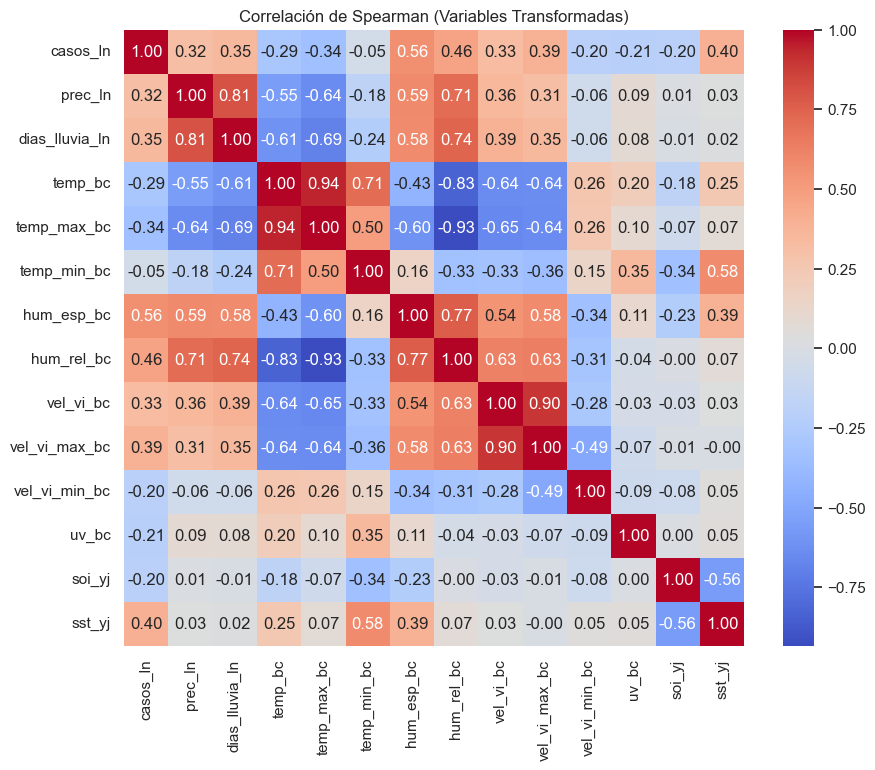


Correlación con casos de dengue (transformados):
                casos_ln
casos_ln        1.000000
hum_esp_bc      0.564113
hum_rel_bc      0.464611
sst_yj          0.397949
vel_vi_max_bc   0.391557
dias_lluvia_ln  0.348841
vel_vi_bc       0.330541
prec_ln         0.317112
temp_min_bc    -0.046010
soi_yj         -0.196389
vel_vi_min_bc  -0.196826
uv_bc          -0.213838
temp_bc        -0.287819
temp_max_bc    -0.339709


In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. Seleccionar SOLO variables transformadas
# =========================

df_corr = datos_procesados[[
    'casos_ln',
    
    # Log
    'prec_ln',
    'dias_lluvia_ln',
    
    # Box-Cox
    'temp_bc',
    'temp_max_bc',
    'temp_min_bc',
    'hum_esp_bc',
    'hum_rel_bc',
    'vel_vi_bc',
    'vel_vi_max_bc',
    'vel_vi_min_bc',
    'uv_bc',
    
    # Yeo-Johnson
    'soi_yj',
    'sst_yj'
]]

# =========================
# 2. Calcular correlación de Spearman
# =========================

corr_spearman = df_corr.corr(method='spearman')

# =========================
# 3. Visualizar matriz completa
# =========================

plt.figure(figsize=(10,8))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlación de Spearman (Variables Transformadas)')
plt.show()

# =========================
# 4. Correlación SOLO con casos de dengue
# =========================

corr_casos = corr_spearman[['casos_ln']].sort_values(by='casos_ln', ascending=False)

print("\nCorrelación con casos de dengue (transformados):")
print(corr_casos)

## Prueba de normalidad

In [52]:
from scipy.stats import shapiro

# Seleccionar solo las columnas numéricas
numericas = datos_procesados.select_dtypes(include=["float64", "int64"]) # esto elimina la fecha de lso atributos a determinar correlacion

#Eliminar año y semana_epi
numericas = numericas.drop(columns=['año', 'semana_epi', 'temp_bc_lambda', 'temp_max_bc_lambda', 'temp_min_bc_lambda', 'hum_esp_bc_lambda', 'hum_rel_bc_lambda', 'vel_vi_bc_lambda', 'vel_vi_max_bc_lambda', 'vel_vi_min_bc_lambda', 'uv_bc_lambda'])

# Aplicar Shapiro-Wilk a cada variable
resultados_normalidad = {}
for col in numericas.columns:
    stat, p = shapiro(numericas[col].dropna())
    resultados_normalidad[col] = {"Estadístico W": stat, "Valor p": p}

# Mostrar resultados
df_normalidad = pd.DataFrame(resultados_normalidad).T
df_normalidad["Normal (p>0.05)"] = df_normalidad["Valor p"] > 0.05
df_normalidad

,Estadístico W,Valor p,Normal (p>0.05)
temp,0.917537,8.004622e-11,False
temp_max,0.883120,2.825387e-13,False
temp_min,0.980537,1.226305e-03,False
hum_esp,0.948490,5.846115e-08,False
hum_rel,0.830594,3.401543e-16,False
prec,0.890732,8.840685e-13,False
dias_lluvia,0.880142,1.833430e-13,False
vel_vi,0.977046,3.204057e-04,False
vel_vi_max,0.964436,4.612705e-06,False
vel_vi_min,0.975928,2.120517e-04,False


In [ ]:
# ====================== CREAR DATAFRAME CON REZAGOS (12 SEMANAS) ======================

# Crear una copia para no modificar el dataframe original
datos_procesados_rezagos = datos_procesados.copy()

# Variables exógenas a las que les quieres crear rezagos
exog_vars = [
    'prec_ln', 'dias_lluvia_ln',
    'temp_bc', 'temp_max_bc', 'temp_min_bc', 'hum_esp_bc', 'hum_rel_bc',
    'vel_vi_bc', 'vel_vi_max_bc', 'vel_vi_min_bc', 'uv_bc',
    'soi_yj', 'sst_yj'
]
# Rezagos deseados: 12 semanas
lags = list(range(1, 13))        # ← Esto crea [1, 2, 3, ..., 12]

# Crear los rezagos
for var in exog_vars:
    for lag in lags:
        datos_procesados_rezagos[f'{var}_lag{lag}'] = datos_procesados_rezagos[var].shift(lag)

# Eliminar las filas con NaN generadas por los rezagos (muy recomendable)
datos_procesados_rezagos = datos_procesados_rezagos.dropna().reset_index(drop=True)

# ====================== MENSAJES FINALES ======================
print("✅ Rezagos creados correctamente (12 semanas)")
print(f"Dimensiones del dataframe con rezagos: {datos_procesados_rezagos.shape}")
print(f"Total de columnas: {len(datos_procesados_rezagos.columns)}")

# Mostrar información de los rezagos
lag_columns = [col for col in datos_procesados_rezagos.columns if '_lag' in col]

print(f"\nTotal de columnas de rezagos creadas: {len(lag_columns)}")
print("\nColumnas de rezagos creadas:")
print(lag_columns)


Aquí tienes el análisis detallado basado en el histograma y los modelos de series temporales que planeas usar:



### 1. ¿Por qué es adecuado aplicar el logaritmo?

El histograma muestra una **asimetría positiva severa** (sesgo a la derecha o *right-skewed*). La gran mayoría de los datos se concentran en valores bajos (cercanos a 0-20), pero tienes una "cola" larga que llega hasta más de 100.



* **Estabilización de la varianza:** En datos de epidemiología (como el dengue), la varianza suele crecer proporcionalmente a la media (a más casos, más fluctuación). El logaritmo ayuda a que la varianza sea constante (**homocedasticidad**), un requisito clave para modelos lineales como ARIMA.


* **Normalización:** Los modelos ARIMA/SARIMA asumen que los residuos del modelo siguen una distribución normal. Al aplicar logaritmo, "comprimes" los valores altos y "expandes" los bajos, haciendo que la distribución se acerque más a una campana de Gauss.


* **Linealización de relaciones:** El dengue suele crecer de forma exponencial durante brotes. El logaritmo convierte ese crecimiento exponencial en uno lineal, que es mucho más fácil de capturar para un modelo ARIMAX.




### 2. Justificación: ¿Es aplicable no hacer preprocesamiento?

Si decides **no** aplicar preprocesamiento (dejar la variable en su escala original), te enfrentarás a varios problemas técnicos que probablemente degraden el rendimiento de tus modelos:

* **Sensibilidad a valores extremos:** Sin preprocesamiento, los picos de casos (outliers visuales en la cola derecha) tendrán un peso desproporcionado en el cálculo del error (MSE). El modelo intentará "perseguir" esos picos y perderá precisión en los periodos normales.
* **Predicciones negativas:** Si no transformas los datos y el modelo detecta una tendencia bajista fuerte cerca de cero, ARIMA podría predecir valores negativos de casos, lo cual es físicamente imposible. Al usar $\log(y)$, la predicción revertida $\exp(\hat{y})$ siempre será positiva.
* **Falta de convergencia:** En SARIMAX, si la estacionalidad es **multiplicativa** (el tamaño de los picos estacionales varía con el nivel de la serie), los modelos ARIMA (que son aditivos por naturaleza) fallarán estrepitosamente a menos que uses el logaritmo para convertir esa relación en aditiva.

---



### 3. Consideraciones para ARIMA, ARIMAX y SARIMAX

Al trabajar con estos modelos específicos, ten en cuenta lo siguiente:

1.  **Manejo de ceros:** Si tienes semanas con **0 casos**, el $\log(0)$ es indefinido. Debes aplicar una transformación $\log(y + 1)$.
2.  **Diferenciación ($d, D$):** Es muy probable que después del logaritmo sigas necesitando diferenciar la serie para hacerla estacionaria. El logaritmo estabiliza la varianza, pero la diferenciación estabiliza la media.
3.  **Variables Exógenas (ARIMAX):** Si usas variables como temperatura o precipitación, asegúrate de evaluar si estas también necesitan transformación. La relación entre "Temperatura" y "$\log(\text{Casos})$" suele ser mucho más robusta estadísticamente.
4.  **Interpretación:** Recuerda que al terminar, deberás aplicar la función inversa ($\exp$) a tus predicciones para volver a la escala original de "número de personas".

**En conclusión:** No preprocesar esta variable sería un error metodológico dado el sesgo visible. La transformación logarítmica es el estándar de oro para este tipo de distribuciones en modelos de series de tiempo.

# Referentes que justifican este preprocesamiento  

Para sustentar tu decisión académica o investigativa, puedes apoyarte en estos 5 referentes y pilares técnicos que validan la transformación logarítmica en modelos de conteo epidemiológico y series temporales:

### 1. Box & Cox (La Transformación de Box-Cox)
George Box y David Cox son los referentes primordiales. Su metodología demuestra que para variables que no son normales y tienen varianza no constante, una transformación de potencia (donde el logaritmo es el caso más común) es esencial para que los modelos lineales sean válidos.
* **Argumento:** Sin esta transformación, violas los supuestos de **homocedasticidad** necesarios para que los estimadores de tu ARIMA sean eficientes.

### 2. Rob J. Hyndman (*Forecasting: Principles and Practice*)
Es probablemente el autor más influyente hoy en día en series de tiempo. En su libro de referencia, explica que si la variación estacional de una serie parece crecer con el nivel de la serie (como ocurre en los brotes de dengue), se debe usar una transformación logarítmica para convertir la **estacionalidad multiplicativa en aditiva**.
* **Argumento:** Los modelos SARIMA estándar son aditivos; el logaritmo es la herramienta para que el modelo "entienda" crecimientos exponenciales.



### 3. Organización Panamericana de la Salud (OPS) - Guías de Vigilancia
En sus manuales técnicos para el análisis de brotes, la OPS recomienda frecuentemente el uso de tasas o transformaciones logarítmicas al graficar y modelar curvas epidémicas para estabilizar la visualización de la tendencia frente a los picos súbitos de casos.
* **Argumento:** El logaritmo ayuda a comparar la tasa de crecimiento entre diferentes periodos, independientemente de la magnitud absoluta del brote.

### 4. Robert Shumway y David Stoffer (*Time Series Analysis and Its Applications*)
Referentes académicos clásicos. Explican que para datos de conteo (como el número de enfermos), la distribución suele seguir una **Poisson** o una **Binomial Negativa**, donde la varianza aumenta con la media.
* **Argumento:** El logaritmo actúa como una "función de enlace" que permite tratar estos datos de conteo dentro del marco de los modelos gaussianos (como ARIMA).

### 5. Estudios de Caso en *The Lancet* o *Nature* (Modelado de Dengue)
Si buscas literatura específica, autores como **Moritz Kraemer** o **Simon Hay**, expertos en mapeo de enfermedades infecciosas, suelen preprocesar los datos de incidencia mediante $\log(n + 1)$ para manejar la sobredispersión de los datos de dengue en climas tropicales.
* **Argumento:** En el mundo real, los datos de dengue tienen muchos "ceros" y "picos". El preprocesamiento no es opcional, es el estándar para evitar que el ruido de los picos domine la señal del modelo.

---

### Resumen para tu investigación:
| Referente | Concepto Clave | Aplicación en tu caso |
| :--- | :--- | :--- |
| **Box-Cox** | Estabilización de varianza | Corregir el sesgo que ves en tu histograma. |
| **Hyndman** | Estacionalidad aditiva | Hacer que SARIMAX funcione correctamente. |
| **OPS** | Curvas Epidémicas | Normalizar la visualización de brotes. |
| **Shumway & Stoffer** | Linealización | Permitir que ARIMAX use regresores externos de forma lineal. |
| **Kraemer / Hay** | $\log(n+1)$ | Manejo de semanas con cero casos y alta dispersión. |

¿Necesitas ayuda con la implementación del código para realizar la transformación inversa tras obtener las predicciones?

# Preprocesamiento de casos_dengue en Python  


In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df_pre= pd.read_excel(r"C:\Users\usuario1\Documents\GitHub\arima\2_ejecucion_plan_trabajo\2_consolidacion_datos_meteoro_epidemiologicos_reales\03_fusionados_y_limpieza_datos\df_final_fusionado.xlsx")
df_pre.head()